In [1]:
%matplotlib widget
import scipp as sc
from drtrex.instrument import Instrument
from drtrex.sample import Sample
from drtrex.components.source import Source


central_wavelength = 1.65 * sc.Unit("Å")
mode = "High Resolution"  # Chopper mode
rrm = 16
T_OFFSET = sc.scalar(1.7, unit="ms")

trex = Instrument(central_wavelength, rrm, mode, T_OFFSET)
trex.source = Source(facility="ess", neutrons=20_000_000, pulses=1)
res_elastic_rrm16 = trex.run()
sample = Sample(en={"uniform": (40, 50)})
res_inelastic_rrm16 = trex.run(sample)

/var/folders/s5/6527bxpx7xnbbzxz94s_d2xm0000gp/T/ipykernel_71240/1279856038.py:12: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


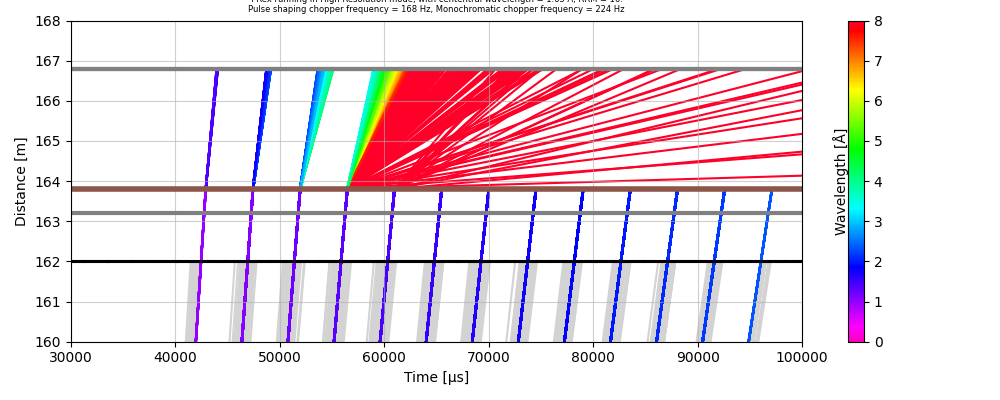

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))

res_inelastic_rrm16.plot(
    visible_rays=20_000_000, blocked_rays=20_000, ax=ax, vmin=0, vmax=8
)
ax.set_xlim([30_000, 100_000])
ax.set_ylim([160, 168])
ax.set_title(str(trex), fontsize=6)
ax.grid(alpha=0.6)
fig.tight_layout()

In [28]:
flux = trex.estimate_flux()
print(flux.values)
ei = trex.estimate_ei(res_elastic_rrm16)
print(ei.values)
bounds = trex.estimate_qe_coverage(res_elastic_rrm16, ei_ef_ratio=0.0)
bounds

[  41 1567 1549 1533 1458 1291 1260 1093 1104 1023 1108 1203   35]
[84.39101598 67.00014544 55.52294367 46.73724845 39.90558159 34.44190637
 30.04944325 26.44622551 23.45012565 20.92804114 18.80427305 16.98272766
 15.25910285]


{'Ei = 84.4 (meV)': <scipp.DataArray>
 Dimensions: Sizes[momentum transfer:398, ]
 Coordinates:
 * momentum transfer         float64           [1/Å]  (momentum transfer)  [0.0801728, 0.160346, ..., 15.8742, 15.9544]
 Data:
                             float64            [meV]  (momentum transfer)  [-2.1337, -4.29403, ..., -102.322, -105.489]
 ,
 'Ei = 67 (meV)': <scipp.DataArray>
 Dimensions: Sizes[momentum transfer:398, ]
 Coordinates:
 * momentum transfer         float64           [1/Å]  (momentum transfer)  [0.0801728, 0.160346, ..., 15.8742, 15.9544]
 Data:
                             float64            [meV]  (momentum transfer)  [-1.90263, -3.83189, ..., -148.073, -151.471]
 ,
 'Ei = 55.5 (meV)': <scipp.DataArray>
 Dimensions: Sizes[momentum transfer:398, ]
 Coordinates:
 * momentum transfer         float64           [1/Å]  (momentum transfer)  [0.0801728, 0.160346, ..., 15.8742, 15.9544]
 Data:
                             float64            [meV]  (momentum transfer)  [-1.7332

In [56]:
lsd = trex.detectors['Detector'].distance - trex.monitors['Monitor at Sample'].distance
def frame_overlap_ratio(en, ts1, ts2, ei2, lsd=lsd):
    return (1+(ts2-ts1).to(unit='s')/lsd*sc.sqrt(2*(ei2-en)/sc.constants.m_n).to(unit='m/s'))**(-3)

In [58]:
ei = trex.estimate_ei(res_elastic_rrm16)
toa = trex.estimate_toa_at('Monitor at Sample', res_elastic_rrm16)

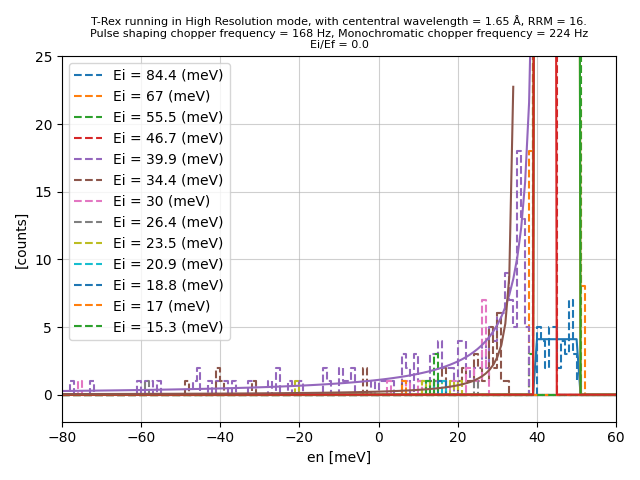

In [71]:
import plopp as pp
import numpy as np
import scipy.stats as stats

ei_ef_ratio = 0.0
params = trex.unwrap_frame(res_elastic_rrm16, ei_ef_ratio=ei_ef_ratio)
reduced_ins = trex.toa_to_energy(res_inelastic_rrm16, *params)
hist_dict = {
    f"Ei = {reduced.coords['ei'].values:.3g} (meV)": reduced.hist(
        en=sc.arange("en", -80, 80, 1, unit="meV")
    )
    for reduced in reduced_ins
}

fig, ax = plt.subplots()
x = np.arange(-80, 80, 1)

p = pp.plot(hist_dict, ax=ax, marker=None, linestyle="--")
ax.plot(x, stats.uniform.pdf(x, loc=40, scale=10) * flux.values[0], color="C0")
ax.plot(x, stats.uniform.pdf(x, loc=40, scale=10) * flux.values[1], color="C1")
ax.plot(x, stats.uniform.pdf(x, loc=40, scale=10) * flux.values[2], color="C2")
scale3 = bounds["Ei = 46.7 (meV)"].values.max() - 40
flux3 = flux.values[3] * scale3 / 10
ax.plot(x, stats.uniform.pdf(x, loc=40, scale=scale3) * flux3, color="C3")
x4=sc.arange("en", -80, 39.9, 1, unit="meV")
ax.plot(x4, frame_overlap_ratio(x4, toa[3], toa[4],ei2=ei[4]) * 150, color="C4",)

x5=sc.arange("en", -80, 34.4, 1, unit="meV")
ax.plot(x5, frame_overlap_ratio(x5, toa[3], toa[5],ei2=ei[5]) * 150, color="C5",)
ax.set_title(str(trex) + f"\nEi/Ef = {ei_ef_ratio}", fontsize=8)
ax.grid(alpha=0.6)
# ax.set_yscale('log')
#ax.set_ylim(bottom=0.1, top=1e3)
ax.set_ylim(bottom=-2, top=25)
ax.set_xlim(left=-80, right=60)
fig.tight_layout()